In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1 Loading & Exploring Data

In this step, we load the dataset and explore its structure to understand the data.

- Display the first rows of the dataset
- Check the number of rows and columns
- Identify data types of each feature

This helps us understand what kind of data we are working with before applying any preprocessing.

In [3]:
df=pd.read_csv('../data/Country-data.csv')
df.sample(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
132,Sierra Leone,160.0,16.8,13.10,34.5,1220,17.200,55.0,5.20,399
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
140,Sri Lanka,11.2,19.6,2.94,26.8,8560,22.800,74.4,2.20,2810
122,Portugal,3.9,29.9,11.00,37.4,27200,0.643,79.8,1.39,22500
74,Israel,4.6,35.0,7.63,32.9,29600,1.770,81.4,3.03,30600
104,Montenegro,6.8,37.0,9.11,62.7,14000,1.600,76.4,1.77,6680
138,South Korea,4.1,49.4,6.93,46.2,30400,3.160,80.1,1.23,22100
22,Brazil,19.8,10.7,9.01,11.8,14500,8.410,74.2,1.80,11200
23,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300
60,Greece,3.9,22.1,10.30,30.7,28700,0.673,80.4,1.48,26900


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
print(df.duplicated().sum())

0


## Checking Missing Values

In [7]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### Exploring the features 

In [8]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()


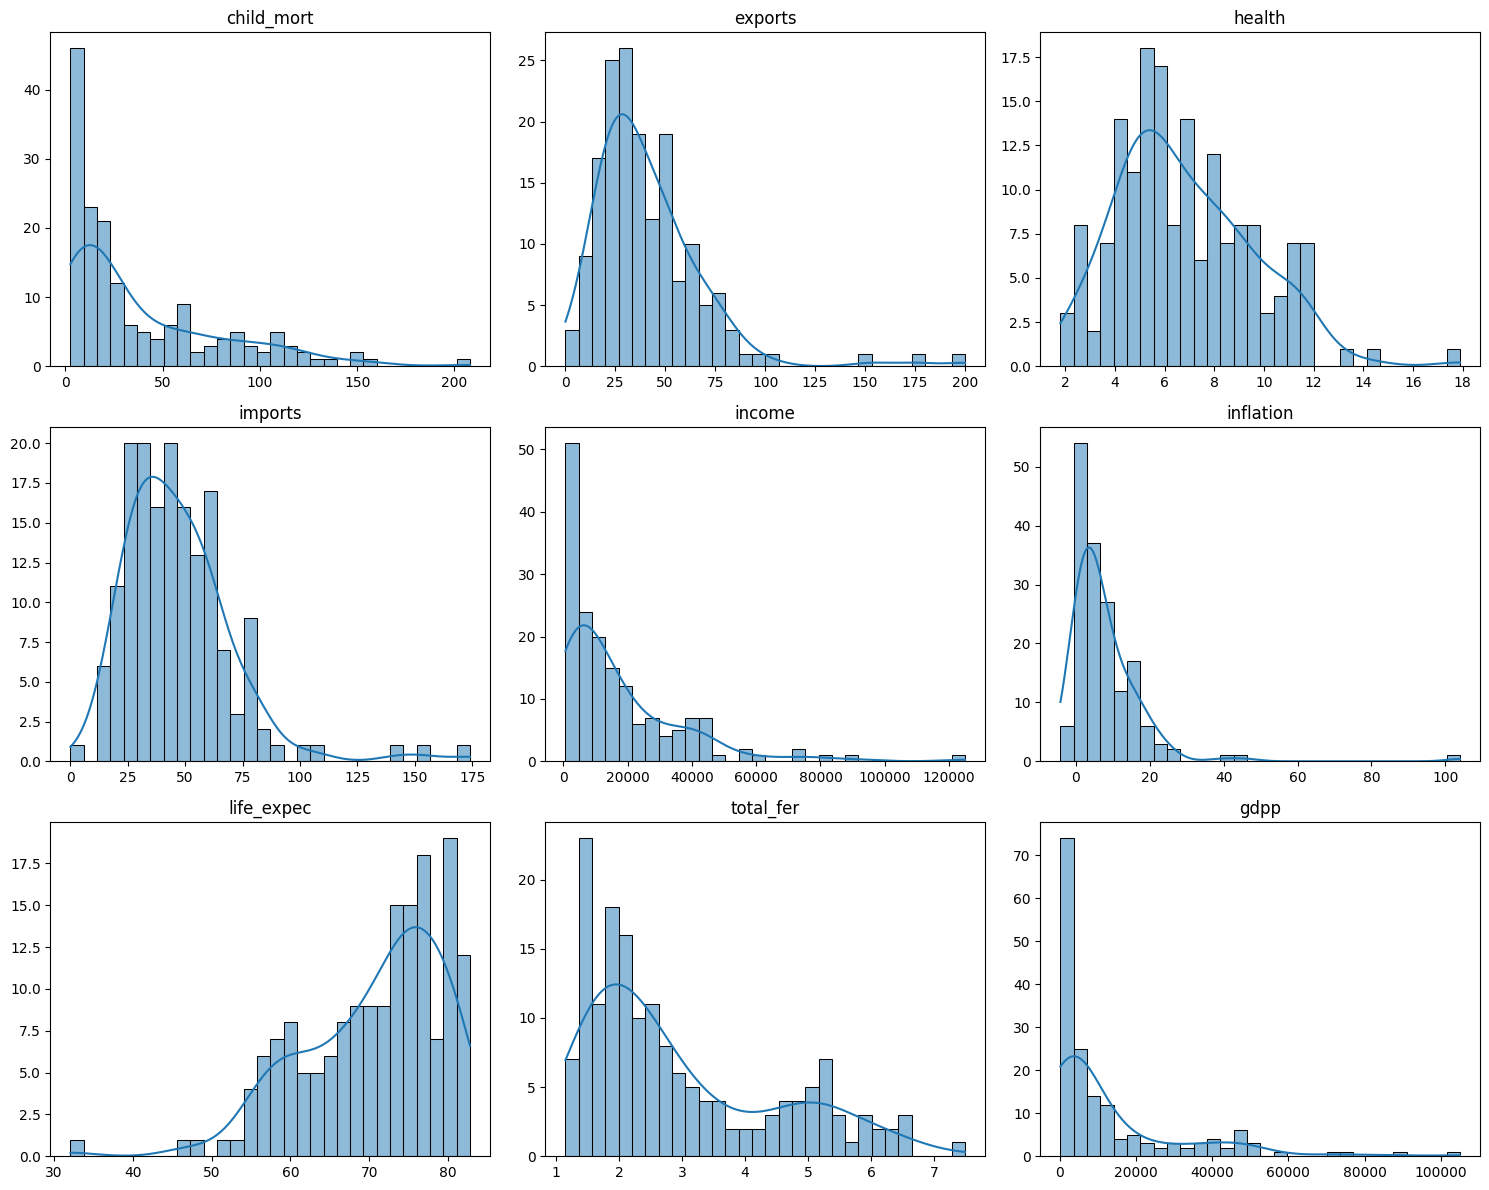

In [9]:
plot_all_histograms(df)

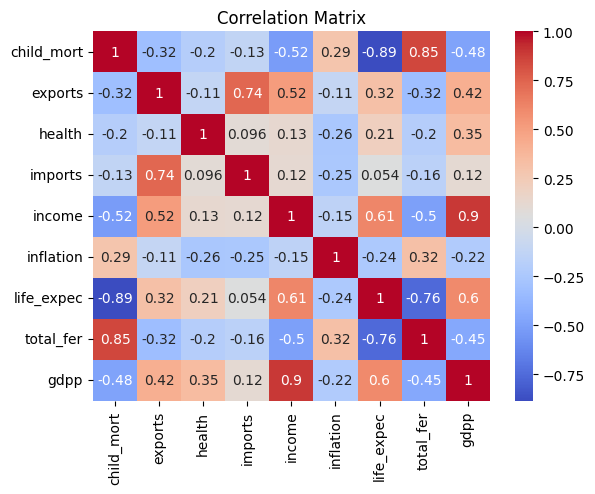

In [10]:
corr = df.drop("country", axis=1).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

From this heatmap, I can define the top 3 highest positive correlation score:

- **gdpp** and income with 0.9
- total_fer and **child_mort** with 0.85
- **imports** and exports with 0.74

I pick one of each correlation pair to see how the cluster will be made from those data. So the next step, I show you clustering between GDPP VS Child Mortality and GDPP VS Imports

In [11]:
df = df[['child_mort', 'imports', 'gdpp']]

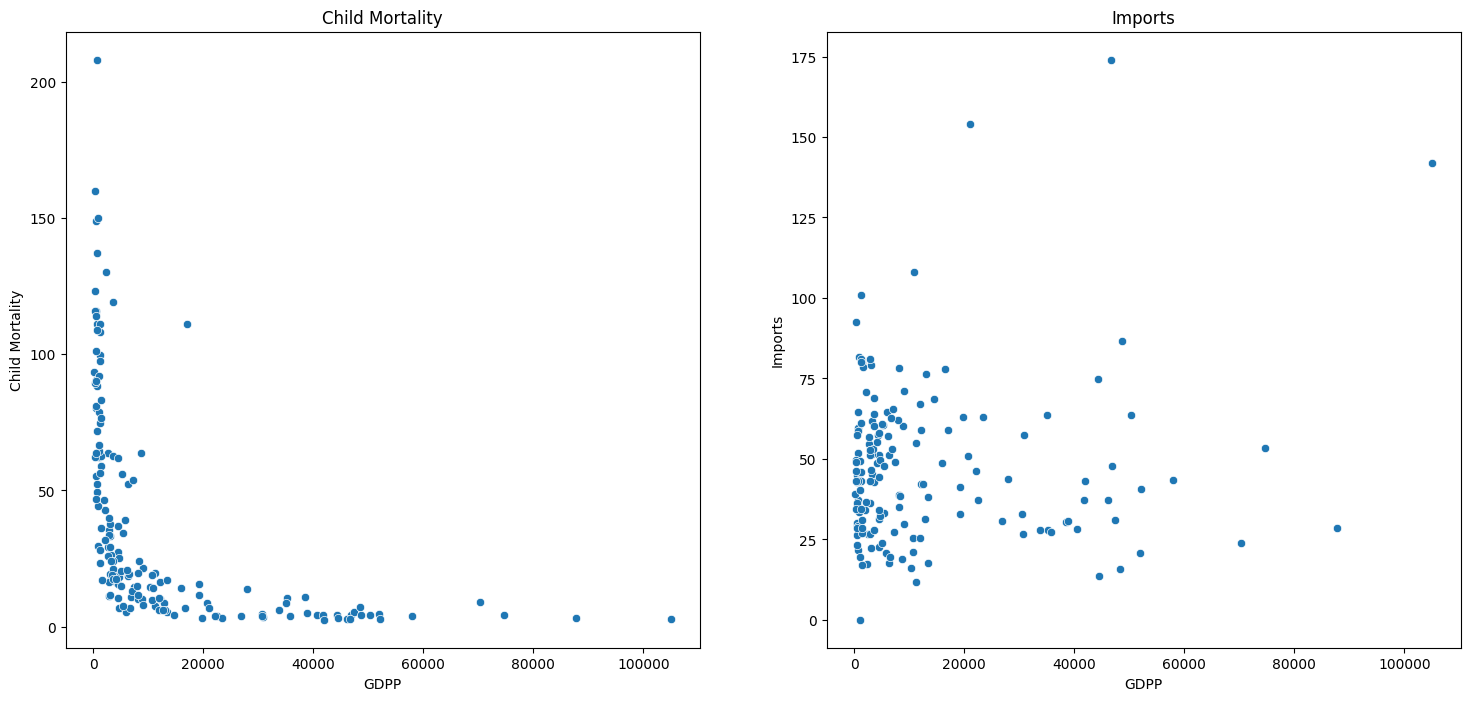

In [13]:
plt.figure(figsize=(18,8))
plt.subplot(1, 2, 1)
sns.scatterplot(x = 'gdpp', y = 'child_mort', data = df)
plt.title('Child Mortality')
plt.xlabel('GDPP')
plt.ylabel('Child Mortality')
plt.subplot(1, 2, 2)
sns.scatterplot(x = 'gdpp', y = 'imports', data = df)
plt.title('Imports')
plt.xlabel('GDPP')
plt.ylabel('Imports')
plt.show()